In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# Step 2: Load Data
df = pd.read_csv('student_data.csv')  # Ensure the file is in the same folder or provide full path

# Step 3: Display first few rows of the dataset to understand its structure
df.head()


,hours_studied,attendance,past_score,extra_activities,pass_fail
0,2.0,70,50,0,0
1,3.0,80,60,1,1
2,5.0,90,75,0,1
3,1.0,60,40,1,0
4,4.0,85,70,0,1


In [4]:
# Step 4: Split data into features (X) and target (y)
X = df[['hours_studied', 'attendance', 'past_score', 'extra_activities']]
y = df['pass_fail']


In [5]:
# Step 5: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [6]:
# Step 6: Scale the features to normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
# Step 7: Initialize and train the model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)


LogisticRegression()

Model Accuracy: 75.00%
Confusion Matrix:
[[0 1]
 [0 3]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.75      1.00      0.86         3

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



E:\sunny\OneDrive\Desktop\Student_Performance_Predictor_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
E:\sunny\OneDrive\Desktop\Student_Performance_Predictor_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
E:\sunny\OneDrive\Desktop\Student_Performance_Predictor_Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont

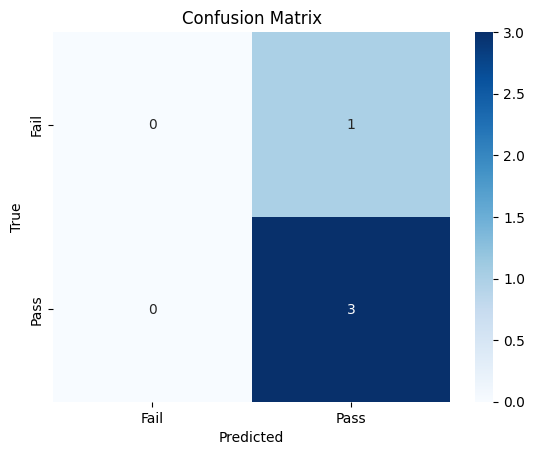

In [8]:
# Step 8: Predict the test set results
y_pred = model.predict(X_test_scaled)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

# Plot Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [9]:
# Step 9: Making Predictions with New Data
input_data = {
    'hours_studied': 4.5,
    'attendance': 80,
    'past_score': 70,
    'extra_activities': 1
}

# Convert input data to DataFrame
input_df = pd.DataFrame([input_data])

# Scale the input data
input_scaled = scaler.transform(input_df)

# Predict with the trained model
prediction = model.predict(input_scaled)
prediction_prob = model.predict_proba(input_scaled)

if prediction[0] == 1:
    print("The student is predicted to pass.")
else:
    print("The student is predicted to fail.")

print(f"Prediction probability: Pass: {prediction_prob[0][1]*100:.2f}%, Fail: {prediction_prob[0][0]*100:.2f}%")


The student is predicted to pass.
Prediction probability: Pass: 85.27%, Fail: 14.73%
